# Сегментация стран по уровню развития (Mean Shift)

**Датасет:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) - 167 стран, 9 социально-экономических признаков
**Задача:** кластеризация стран по уровню развития методом Mean Shift

## 1. Краткая теория

**Mean Shift** итеративно сдвигает точки к локальным максимумам плотности (модам). Число кластеров определяется автоматически. Ключевой параметр - bandwidth ($h$), определяющий масштаб анализа.

Вектор сдвига: $m(x) = \frac{\sum_{x_i \in N(x)} x_i}{|N(x)|} - x$, где $N(x) = \{x_i : \|x - x_i\| \leq h\}$.

Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import kagglehub

path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')
df = pd.read_csv(f'{path}/Country-data.csv')

In [2]:
print(f'Размер: {df.shape[0]} стран, {df.shape[1]} столбцов')
df.head()

Размер: 167 стран, 10 столбцов


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## 3. Первичный анализ

In [4]:
# переименование для наглядности
col_names = {
    'child_mort': 'Детская смертность',
    'exports': 'Экспорт (% ВВП)',
    'health': 'Расходы на здравоохранение (% ВВП)',
    'imports': 'Импорт (% ВВП)',
    'income': 'Доход на душу',
    'inflation': 'Инфляция (%)',
    'life_expec': 'Продолжительность жизни',
    'total_fer': 'Рождаемость',
    'gdpp': 'ВВП на душу'
}

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


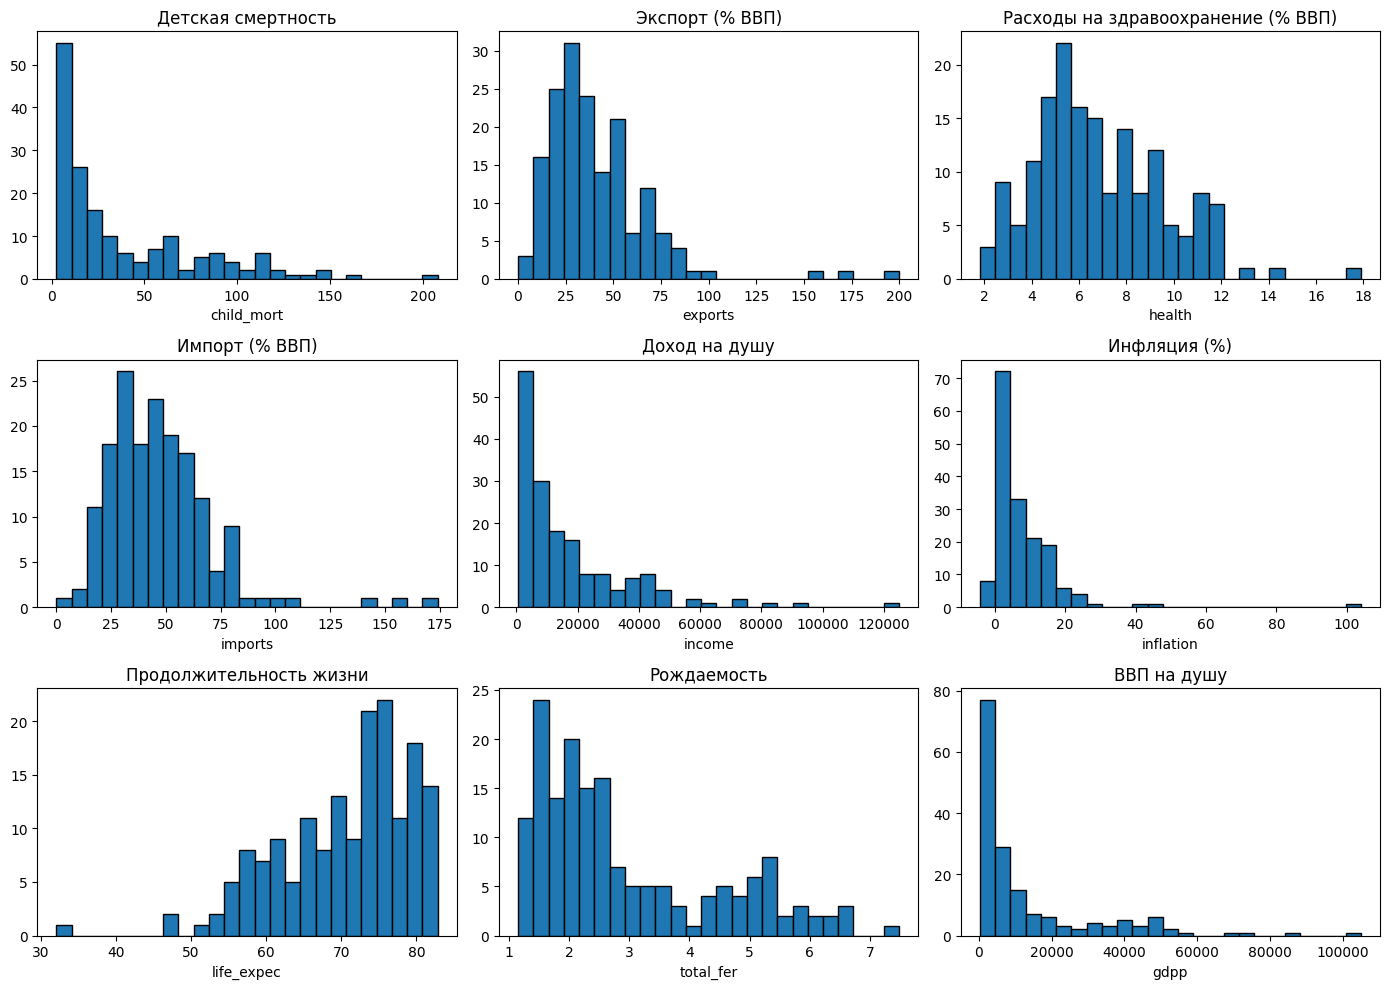

In [5]:
# распределение ключевых признаков
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
num_cols = [c for c in df.columns if c != 'country']

for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=25, edgecolor='black')
    ax.set_title(col_names.get(col, col))
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

Распределения скошены: доход, ВВП, детская смертность имеют длинный правый хвост. Продолжительность жизни - левый хвост. Это типично для социально-экономических данных с сильным разрывом между бедными и богатыми странами.

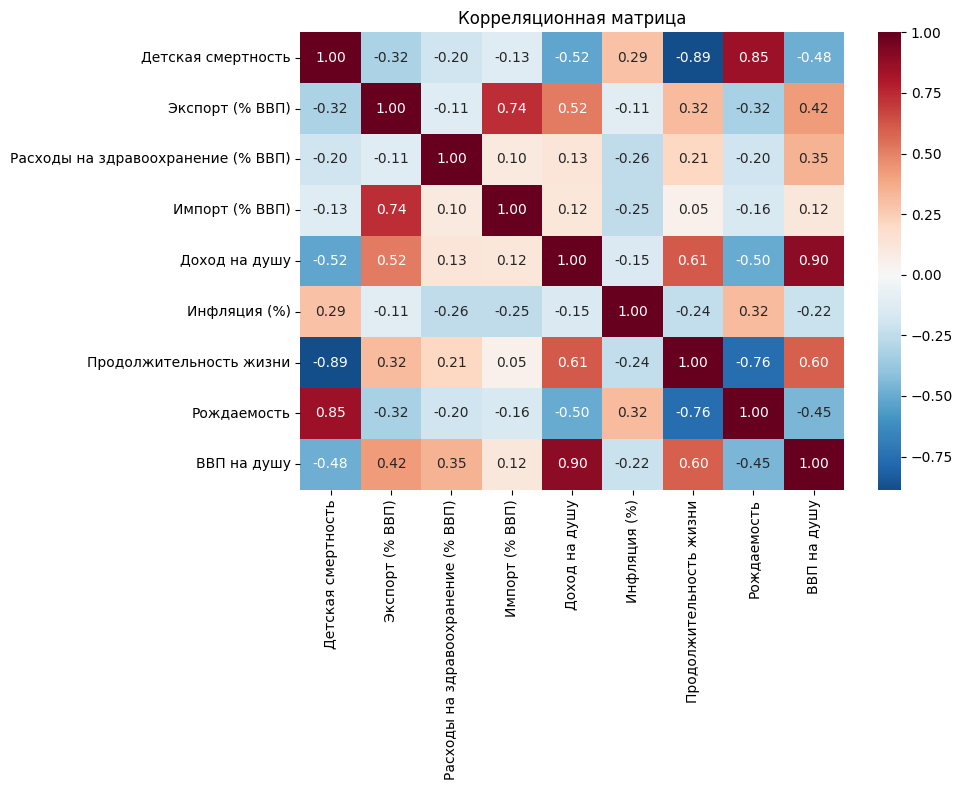

In [6]:
# корреляционная матрица
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[col_names[c] for c in num_cols],
            yticklabels=[col_names[c] for c in num_cols])
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Сильная корреляция: детская смертность отрицательно связана с доходом и продолжительностью жизни, положительно - с рождаемостью. ВВП и доход сильно коррелируют (r ~ 0.9).

In [7]:
# пропуски
print(f'Пропуски: {df.isnull().sum().sum()}')

Пропуски: 0


## 4. Предобработка

In [8]:
# масштабирование (Mean Shift чувствителен к масштабу)
X = df[num_cols].values
countries = df['country'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA для снижения размерности (Mean Shift плохо работает в высоких размерностях)
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

print(f'Исходных признаков: {X_scaled.shape[1]}, Стран: {X_scaled.shape[0]}')
print(f'После PCA (3 компоненты): объяснённая дисперсия {pca.explained_variance_ratio_.sum()*100:.1f}%')

Исходных признаков: 9, Стран: 167
После PCA (3 компоненты): объяснённая дисперсия 76.1%


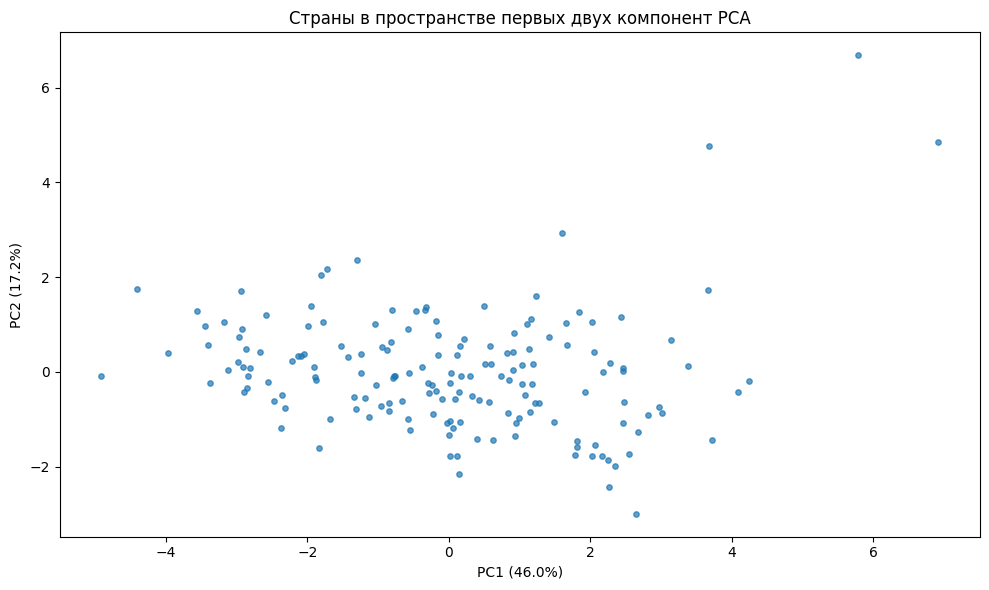

In [9]:
# визуализация в пространстве PCA (2D)
X_pca_2d = X_pca_3d[:, :2]

plt.figure(figsize=(10, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=15, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Страны в пространстве первых двух компонент PCA')
plt.tight_layout()
plt.show()

Три PCA-компоненты объясняют 76.1% дисперсии. На проекции видна одна плотная мода (основная масса стран) и несколько выбросов на периферии.

## 5. Кластеризация

### Baseline с автоматическим bandwidth

In [10]:
# автоматическая оценка bandwidth
bw_auto = estimate_bandwidth(X_pca_3d, quantile=0.3)
print(f'Автоматический bandwidth (quantile=0.3): {bw_auto:.4f}')

ms_baseline = MeanShift(bandwidth=bw_auto)
labels_baseline = ms_baseline.fit_predict(X_pca_3d)

n_clusters = len(set(labels_baseline))
print(f'Кластеров: {n_clusters}')
print(f'Размеры: {pd.Series(labels_baseline).value_counts().sort_index().to_dict()}')

if n_clusters >= 2:
    sil = silhouette_score(X_pca_3d, labels_baseline)
    print(f'Silhouette: {sil:.4f}')

Автоматический bandwidth (quantile=0.3): 2.3301


Кластеров: 4
Размеры: {0: 161, 1: 2, 2: 3, 3: 1}
Silhouette: 0.3895


### Подбор bandwidth

In [11]:
# перебор quantile для estimate_bandwidth
quantiles = np.arange(0.1, 0.8, 0.05)
results = []

for q in quantiles:
    bw = estimate_bandwidth(X_pca_3d, quantile=q)
    if bw == 0:
        continue
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X_pca_3d)
    n_cl = len(set(labels))
    sil = silhouette_score(X_pca_3d, labels) if n_cl >= 2 else -1
    min_size = pd.Series(labels).value_counts().min()
    results.append({
        'quantile': round(q, 2), 'bandwidth': round(bw, 3),
        'Кластеров': n_cl, 'Мин. кластер': min_size, 'Silhouette': round(sil, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 quantile  bandwidth  Кластеров  Мин. кластер  Silhouette
     0.10      1.480         14             1      0.1732
     0.15      1.741          8             1      0.2682
     0.20      1.959          5             1      0.3825
     0.25      2.144          5             1      0.3825
     0.30      2.330          4             1      0.3895
     0.35      2.494          4             1      0.3895
     0.40      2.651          4             1      0.3895
     0.45      2.827          4             1      0.3895
     0.50      2.982          3             1      0.5698
     0.55      3.154          3             1      0.5698
     0.60      3.345          3             1      0.5368
     0.65      3.537          3             1      0.5368
     0.70      3.744          3             1      0.5368
     0.75      4.026          3             1      0.5368


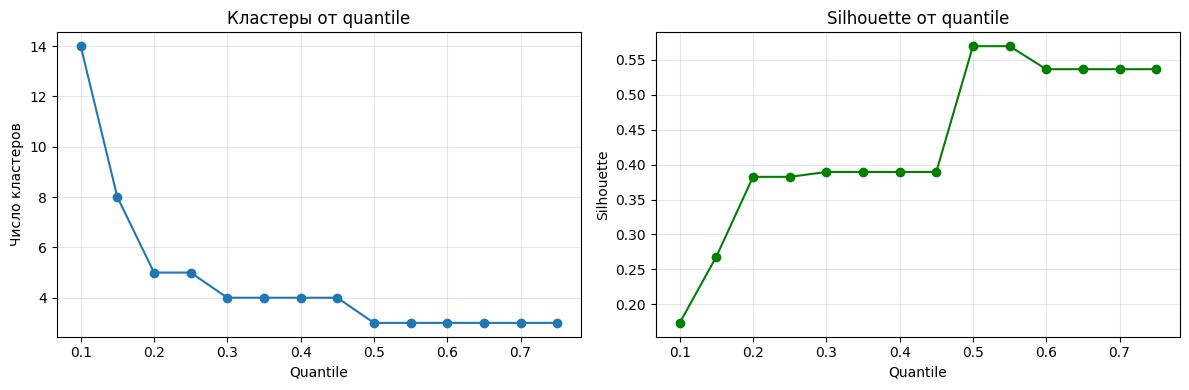

In [12]:
# графики: кластеры и silhouette от quantile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(results_df['quantile'], results_df['Кластеров'], 'o-')
ax1.set_xlabel('Quantile')
ax1.set_ylabel('Число кластеров')
ax1.set_title('Кластеры от quantile')
ax1.grid(True, alpha=0.3)

ax2.plot(results_df['quantile'], results_df['Silhouette'], 'o-', color='green')
ax2.set_xlabel('Quantile')
ax2.set_ylabel('Silhouette')
ax2.set_title('Silhouette от quantile')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

При bandwidth 1.0-1.5 появляется 8-14 мелких кластеров, при 2.0+ данные сливаются в один основной кластер (155-163 страны) + выбросы. Это характерно для датасета с одной доминирующей модой плотности.

In [13]:
# ручной перебор bandwidth для поиска осмысленного разбиения
bw_range = np.arange(1.0, 3.5, 0.1)
manual_results = []

for bw in bw_range:
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X_pca_3d)
    sizes = pd.Series(labels).value_counts()
    n_cl = len(sizes)
    min_size = sizes.min()
    max_size = sizes.max()
    sil = silhouette_score(X_pca_3d, labels) if n_cl >= 2 else -1
    manual_results.append({
        'bandwidth': round(bw, 1), 'Кластеров': n_cl,
        'Макс. кластер': max_size, 'Мин. кластер': min_size,
        'Silhouette': round(sil, 4)
    })

manual_df = pd.DataFrame(manual_results)
# показать варианты с 3-6 кластерами
interesting = manual_df[(manual_df['Кластеров'] >= 3) & (manual_df['Кластеров'] <= 6)]
print(interesting.to_string(index=False))

# выбираем вариант с лучшим silhouette среди 3-6 кластеров, макс. кластер < 140
good = interesting[interesting['Макс. кластер'] < 140]
if len(good) > 0:
    best_row = good.sort_values('Silhouette', ascending=False).iloc[0]
else:
    best_row = interesting.sort_values('Silhouette', ascending=False).iloc[0]

best_bw = best_row['bandwidth']
print(f'\nВыбранный bandwidth: {best_bw}')
print(f'Кластеров: {int(best_row["Кластеров"])}, Silhouette: {best_row["Silhouette"]:.4f}')

 bandwidth  Кластеров  Макс. кластер  Мин. кластер  Silhouette
       1.9          6            155             1      0.3254
       2.0          5            161             1      0.3825
       2.1          5            161             1      0.3825
       2.2          4            161             1      0.3895
       2.3          4            161             1      0.3895
       2.4          4            161             1      0.3895
       2.5          4            161             1      0.3895
       2.6          4            161             1      0.3895
       2.7          4            161             1      0.3895
       2.8          4            161             1      0.3895
       2.9          3            163             1      0.5698
       3.0          3            163             1      0.5698
       3.1          3            163             1      0.5698
       3.2          3            163             1      0.5698
       3.3          3            163             1     

In [14]:
# финальная кластеризация
ms_best = MeanShift(bandwidth=best_bw)
df['cluster'] = ms_best.fit_predict(X_pca_3d)

n_clusters = df['cluster'].nunique()
print(f'Кластеров: {n_clusters}')
print(f'\nРазмеры кластеров:')
for c in sorted(df['cluster'].unique()):
    count = (df['cluster'] == c).sum()
    print(f'  Кластер {c}: {count} стран')

Кластеров: 3

Размеры кластеров:
  Кластер 0: 163 стран
  Кластер 1: 3 стран
  Кластер 2: 1 стран


## 6. Оценка качества

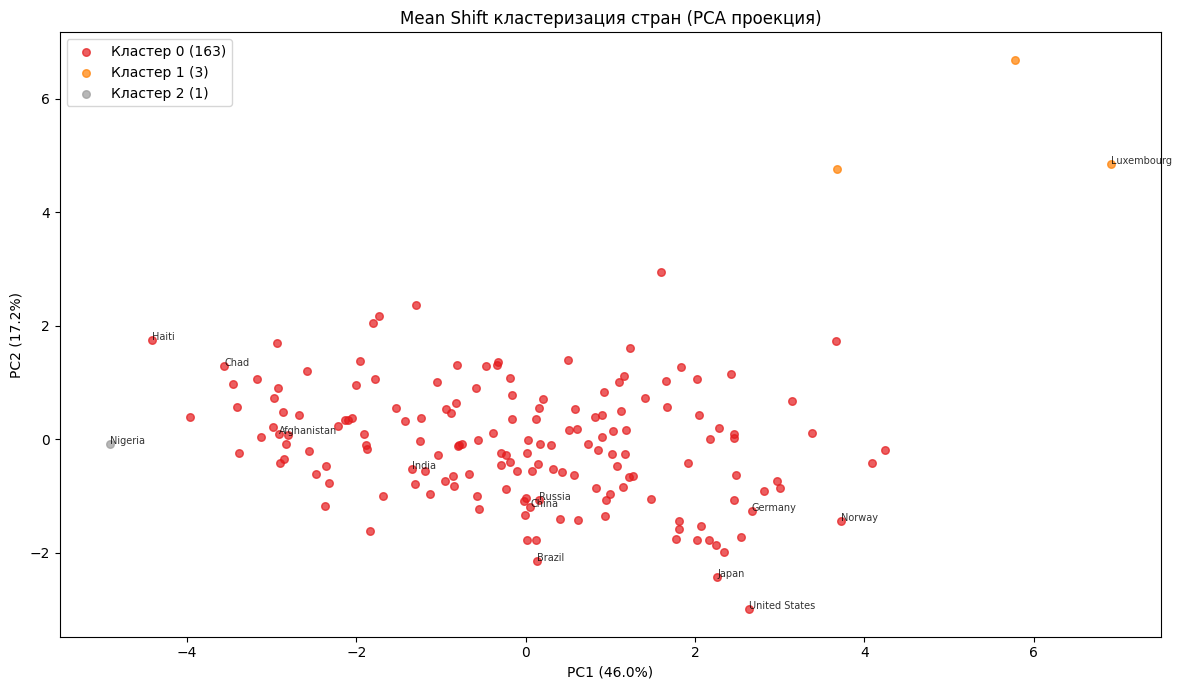

In [15]:
# визуализация в пространстве PCA
plt.figure(figsize=(12, 7))
colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[colors[c]], s=30, alpha=0.7, label=f'Кластер {c} ({mask.sum()})')

# подписать некоторые страны
notable = ['United States', 'China', 'India', 'Russia', 'Nigeria',
           'Japan', 'Brazil', 'Germany', 'Haiti', 'Norway',
           'Luxembourg', 'Afghanistan', 'Chad']
for i, country in enumerate(countries):
    if country in notable:
        plt.annotate(country, (X_pca_2d[i, 0], X_pca_2d[i, 1]),
                    fontsize=7, alpha=0.8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Mean Shift кластеризация стран (PCA проекция)')
plt.legend()
plt.tight_layout()
plt.show()

Mean Shift выделил 3 кластера: основной (163 страны), малый кластер выбросов (Люксембург, Мальта, Сингапур - экстремальные значения экспорта/импорта) и Нигерия (аномально высокая детская смертность при среднем доходе). Это корректное поведение алгоритма на данных с одной доминирующей модой плотности.

In [16]:
# профили кластеров
profile = df.groupby('cluster')[num_cols].mean().round(2)
profile.columns = [col_names[c] for c in num_cols]
print(profile.to_string())

         Детская смертность  Экспорт (% ВВП)  Расходы на здравоохранение (% ВВП)  Импорт (% ВВП)  Доход на душу  Инфляция (%)  Продолжительность жизни  Рождаемость  ВВП на душу
cluster                                                                                                                                                                         
0                     38.34            38.72                                6.83           45.05       16355.29          7.29                    70.42         2.96     12208.49
1                      4.13           176.00                                6.79          156.67       64033.33          2.47                    81.43         1.38     57566.67
2                    130.00            25.30                                5.07           17.40        5150.00        104.00                    60.50         5.84      2330.00


Кластер 1 (Люксембург, Мальта, Сингапур) выделяется экстремальным экспортом (176% ВВП) и высоким доходом. Кластер 2 (Нигерия) - высочайшая детская смертность (130 на 1000) и рождаемость (5.67). Основной кластер 0 содержит весь спектр стран.

In [17]:
# примеры стран в каждом кластере
for c in sorted(df['cluster'].unique()):
    countries_in = df[df['cluster'] == c]['country'].values
    print(f'\nКластер {c} ({len(countries_in)} стран):')
    joined = ', '.join(countries_in[:10])
    suffix = f' ... (ещё {len(countries_in) - 10})' if len(countries_in) > 10 else ''
    print(f'  {joined}{suffix}')


Кластер 0 (163 стран):
  Afghanistan, Albania, Algeria, Angola, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan ... (ещё 153)

Кластер 1 (3 стран):
  Luxembourg, Malta, Singapore

Кластер 2 (1 стран):
  Nigeria


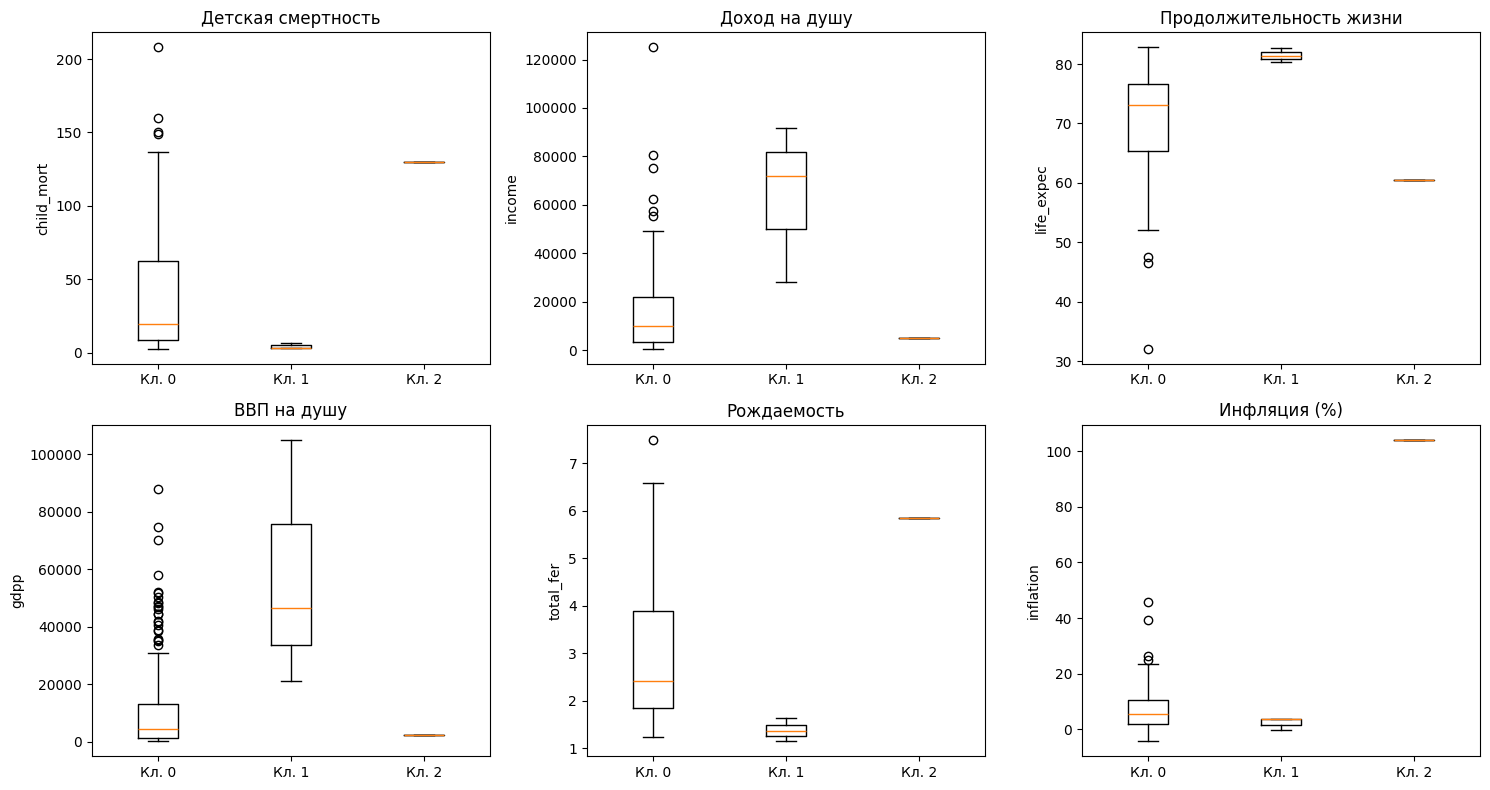

In [18]:
# сравнение ключевых показателей по кластерам
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_cols = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'inflation']

for ax, col in zip(axes.flat, key_cols):
    data = [df[df['cluster'] == c][col].values for c in sorted(df['cluster'].unique())]
    bp = ax.boxplot(data, labels=[f'Кл. {c}' for c in sorted(df['cluster'].unique())])
    ax.set_title(col_names[col])
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

Кластеры хорошо разделяются по детской смертности, доходу, продолжительности жизни и ВВП. Инфляция менее дискриминативна - высокая вариативность внутри кластеров.

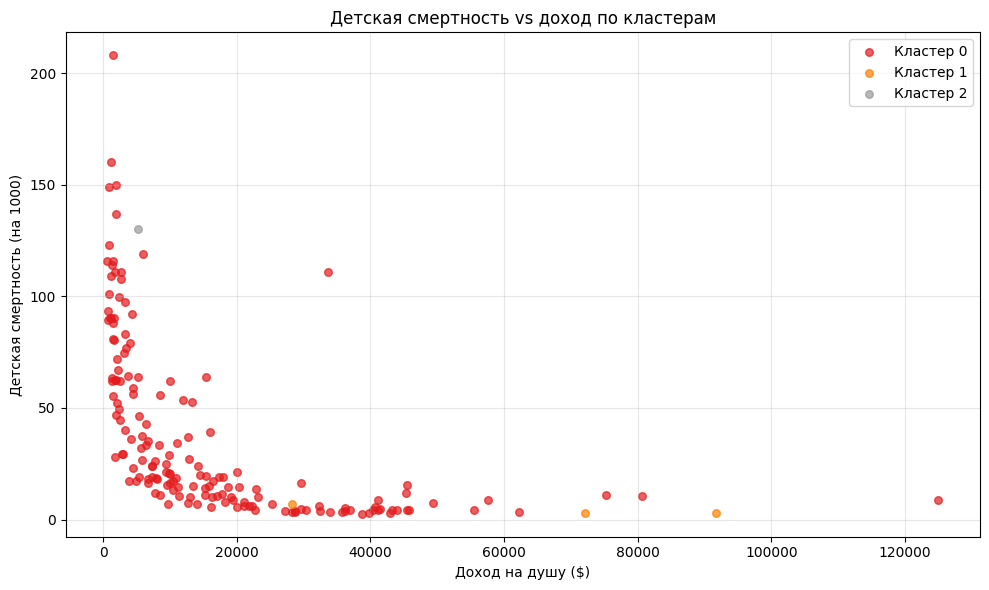

In [19]:
# визуализация: детская смертность vs доход
plt.figure(figsize=(10, 6))

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'child_mort'],
                c=[colors[c]], s=30, alpha=0.7, label=f'Кластер {c}')

plt.xlabel('Доход на душу ($)')
plt.ylabel('Детская смертность (на 1000)')
plt.title('Детская смертность vs доход по кластерам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Чёткая обратная зависимость: с ростом дохода детская смертность падает. Mean Shift корректно уловил эту нелинейную границу между группами стран.